In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from ipynb.fs.defs.AIT26_Tutorial4_RL import transition_probs_from_map, plot_gridworld_with_q, Q_learning

In [2]:
T = np.array([
    [[1, 1, 6/9, 6/9], [0, 0, 3/9, 0], [0, 0, 0, 0], [0, 0, 0, 3/9], [0, 0, 0, 0], [0, 0, 0, 0]],
    [[3/9, 0, 0, 0], [6/9, 1, 6/9, 1], [0, 0, 3/9, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]],
    [[0, 0, 0, 0], [3/9, 0, 0, 0], [6/9, 1, 1, 6/9], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 3/9]],

    [[0, 3/9, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [1, 6/9, 8/9, 1], [0, 0, 1/9, 0], [0, 0, 0, 0]],
    [[0, 0, 0, 0], [0, 1/4, 0, 0], [0, 0, 0, 0], [1/4, 0, 0, 0], [3/4, 3/4, 3/4, 1], [0, 0, 1/4, 0]],
    [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [1, 1, 1, 1], [0, 0, 0, 0], [0, 0, 0, 0]]
])

R = np.array([0, 0, 0, 0, 0, 3])

large_map = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 3, 3, 3],
    [0, 0, 0, 0, 0, 0, 3, 3, 3],
    [0, 0, 0, 1, 1, 1, 3, 3, 3]
]

small_map = [
    [0, 0, 0],
    [0, .75, 3]
]

small_init_state = 3
large_init_state = 36
T_map, R_map = transition_probs_from_map(large_map, start_state=large_init_state)
T_smap, R_smap = transition_probs_from_map(small_map, start_state=small_init_state)

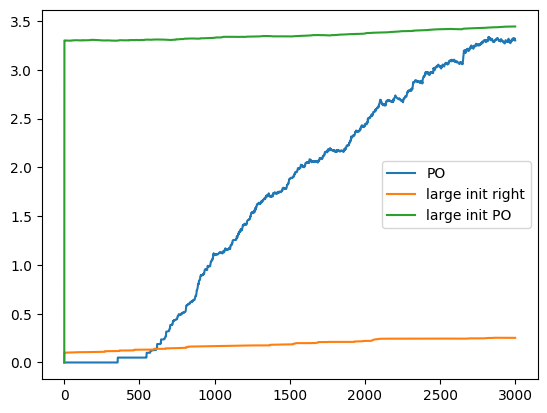

In [3]:
def coarse_grain_Q(small_map, large_map, Q_po):
    srow, scol = len(small_map), len(small_map[0])
    lrow, lcol = len(large_map), len(large_map[0])
    scale_coeff = int(lrow / srow)
    Q_init_coarse = np.zeros((lrow * lcol, Q_po.shape[1]))
    for sr in range(srow):
        for sc in range(scol):
            for lr in range(sr * scale_coeff, (sr + 1) * scale_coeff):
                for lc in range(sc * scale_coeff, (sc + 1) * scale_coeff):
                    s_state = sr * scol + sc
                    l_state = lr * lcol + lc
                    Q_init_coarse[l_state, :] = Q_po[s_state, :]
    return Q_init_coarse

gamma = 0.85
q_steps = 3000
alpha = 0.1
epsilon = 0.1

Q_init_right = np.zeros((T_map.shape[0], T_map.shape[2]))
Q_init_right[:, 2] = 0.1

vs_q_po, Q_po = Q_learning(T, R, gamma, q_steps, alpha, epsilon, small_init_state)
plt.plot(vs_q_po, label='PO')
vs_q_lm_ir, Q_large_right = Q_learning(T_map, R_map, gamma, q_steps, alpha, epsilon, large_init_state, Q_init=Q_init_right)
plt.plot(vs_q_lm_ir, label="large init right")
vs_q_lm_ipo, Q_large_poinit = Q_learning(T_map, R_map, gamma, q_steps, alpha, epsilon, large_init_state, Q_init=coarse_grain_Q(small_map, large_map, Q_po))
plt.plot(vs_q_lm_ipo, label="large init PO")
# vs_q_lm, Q_large_noinit = Q_learning(T_map, R_map, gamma, q_steps, alpha, epsilon, large_init_state, Q_init=None)
# plt.plot(vs_q_lm, label="large")
plt.legend()

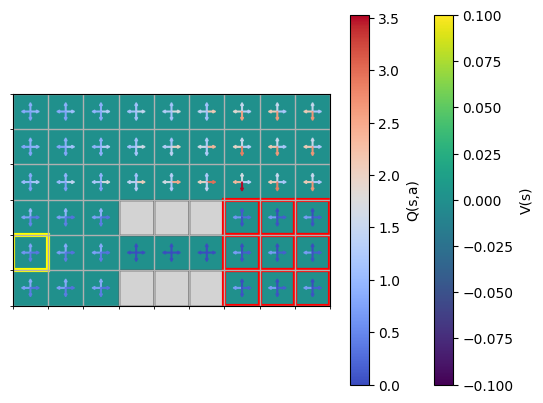

In [5]:
plot_gridworld_with_q(large_map, Q_large_poinit, large_init_state)

Redo 1/5
Redo 2/5
Redo 3/5
Redo 4/5
Redo 5/5


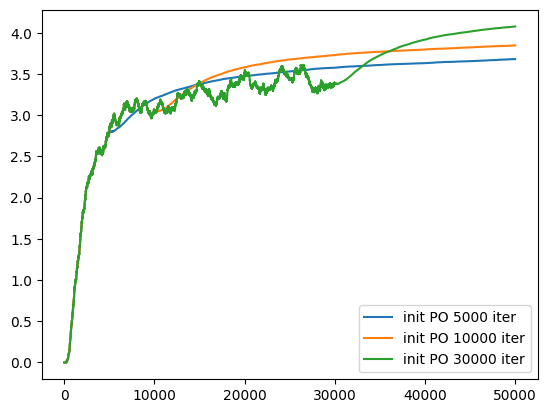

In [38]:
gamma = 0.85
coarse_iterations = [5000, 10000, 30000]
full_iterations = 50000
random_seed = 1
random.seed(random_seed)
np.random.seed(random_seed)

n_redo = 5
all_vs = np.zeros((n_redo, len(coarse_iterations), full_iterations))

for redo_idx in range(n_redo):
    print("Redo %d/%d" % (redo_idx + 1, n_redo))
    Q_po = None
    vs_q_po = []
    for c_it_idx, c_it in enumerate(coarse_iterations):
        #print("Init %d/%d" % (c_it_idx + 1, len(coarse_iterations)))
        #vs_q_po, Q_po = Q_learning(T, R, gamma, c_it, alpha, epsilon, small_init_state)
        n_ci_step = c_it if c_it_idx == 0 else c_it - coarse_iterations[c_it_idx - 1]
        vs_q_po_act, Q_po = Q_learning(T, R, gamma, n_ci_step, alpha, epsilon, small_init_state, Q_init=Q_po)
        vs_q_po = vs_q_po + vs_q_po_act[1:]
        vs_q_lm, _ = Q_learning(T_map, R_map, gamma, full_iterations - c_it, alpha, epsilon, large_init_state, Q_init=coarse_grain_Q(small_map, large_map, Q_po))
        all_vs[redo_idx, c_it_idx, :] = np.array(vs_q_po + vs_q_lm[1:])

for c_it_idx, c_it in enumerate(coarse_iterations):
    #plt.plot(vs_q_po + vs_q_lm[1:], label="init PO %d iter" % c_it)
    plt.plot(all_vs[:, c_it_idx, :].mean(axis=0), label="init PO %d iter" % c_it)
plt.legend()